# LoanShield: Exploratory Data Analysis (EDA)


# 1. Import Libraries


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration for clearer plots


In [6]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# 2. Load Dataset

In [7]:
df = pd.read_csv("../data/raw/Loan_default_raw.csv")

## Part 1: Data Structure & Cleaning

# Q1: Dimensions of the dataset

In [8]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 255347, Columns: 18


# Q2: Data types

In [9]:
print("\nData Types:")
print(df.dtypes)


Data Types:
LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object


# Q3: Missing values

In [10]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


# Q4: Duplicate rows

In [11]:
print(f"\nDuplicate Rows: {df.duplicated().sum()}")


Duplicate Rows: 0


# Q5: Statistical Summary

In [12]:
print("\nStatistical Summary (Numerical):")
display(df.describe())


Statistical Summary (Numerical):


,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


## Part 2: Univariate Analysis (Single Variable)

# Q6: Distribution of Target Variable (Default)

C:\Users\DHAVAL TALAVIYA\AppData\Local\Temp\ipykernel_17848\342634943.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Default', data=df, palette='coolwarm')


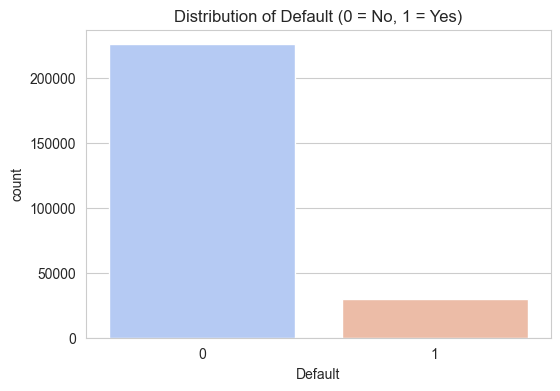

Non-Default (0): 88.39%
Default (1): 11.61%


In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Default', data=df, palette='coolwarm')
plt.title("Distribution of Default (0 = No, 1 = Yes)")
plt.show()

# Calculate imbalance ratio
default_percent = (df['Default'].value_counts(normalize=True) * 100)
print(f"Non-Default (0): {default_percent[0]:.2f}%")
print(f"Default (1): {default_percent[1]:.2f}%")

# Q7: Distribution of Age

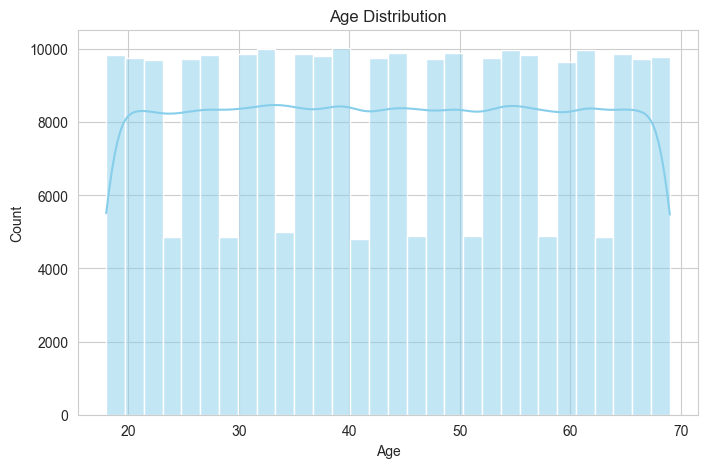

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution")
plt.show()

# Q8: Distribution of Income

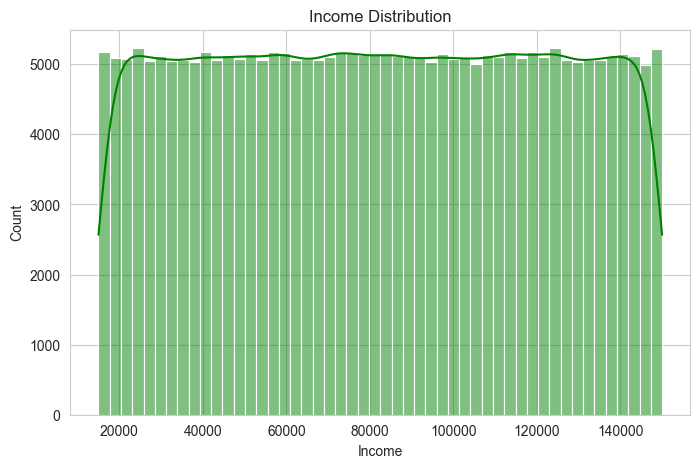

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(df['Income'], bins=50, kde=True, color='green')
plt.title("Income Distribution")
plt.show()

# Q9: Loan Amount Distribution

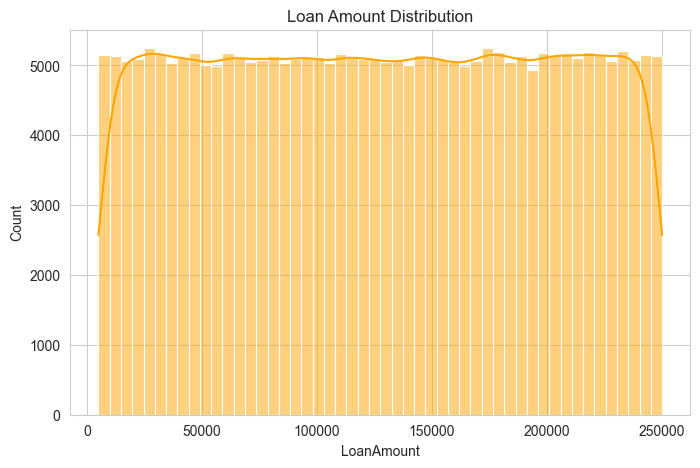

In [16]:
plt.figure(figsize=(8, 5))
sns.histplot(df['LoanAmount'], bins=50, kde=True, color='orange')
plt.title("Loan Amount Distribution")
plt.show()

# Q10: Categorical Value Counts

In [17]:
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'LoanID': # Skip ID column
        print(f"\nValue Counts for {col}:")
        print(df[col].value_counts())


Value Counts for Education:
Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

Value Counts for EmploymentType:
EmploymentType
Part-time        64161
Unemployed       63824
Self-employed    63706
Full-time        63656
Name: count, dtype: int64

Value Counts for MaritalStatus:
MaritalStatus
Married     85302
Divorced    85033
Single      85012
Name: count, dtype: int64

Value Counts for HasMortgage:
HasMortgage
Yes    127677
No     127670
Name: count, dtype: int64

Value Counts for HasDependents:
HasDependents
Yes    127742
No     127605
Name: count, dtype: int64

Value Counts for LoanPurpose:
LoanPurpose
Business     51298
Home         51286
Education    51005
Other        50914
Auto         50844
Name: count, dtype: int64

Value Counts for HasCoSigner:
HasCoSigner
Yes    127701
No     127646
Name: count, dtype: int64


# Q11: Employment Type Counts

C:\Users\DHAVAL TALAVIYA\AppData\Local\Temp\ipykernel_17848\1314497014.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='EmploymentType', data=df, order=df['EmploymentType'].value_counts().index, palette='viridis')


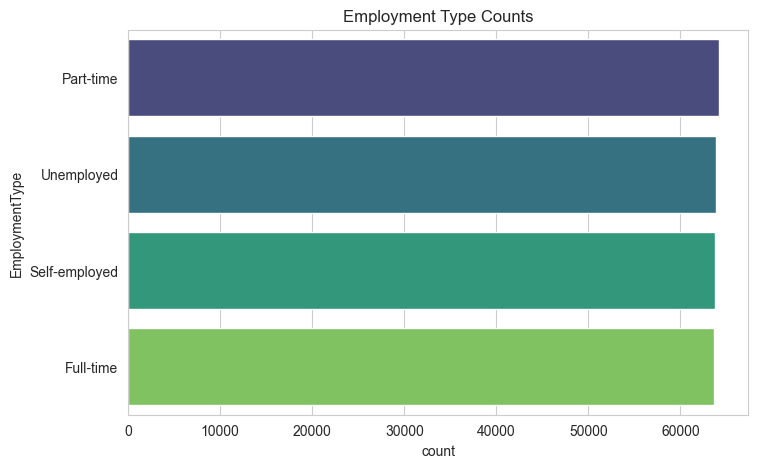

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(y='EmploymentType', data=df, order=df['EmploymentType'].value_counts().index, palette='viridis')
plt.title("Employment Type Counts")
plt.show()

# Q12: Groupby Analysis (Mean values by Default)

In [19]:
print(df.groupby('Default')[['Age', 'Income', 'CreditScore', 'LoanAmount']].mean())

               Age        Income  CreditScore     LoanAmount
Default                                                     
0        44.409962  83899.165995   576.232270  125353.656017
1        36.559539  71844.722659   559.286143  144515.311469


## Part 3: Bivariate Analysis (Relationships)

# Q13: Average Income for Defaulters vs Non-Defaulters

C:\Users\DHAVAL TALAVIYA\AppData\Local\Temp\ipykernel_17848\1086517817.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Default', y='Income', data=df, palette='Set2')


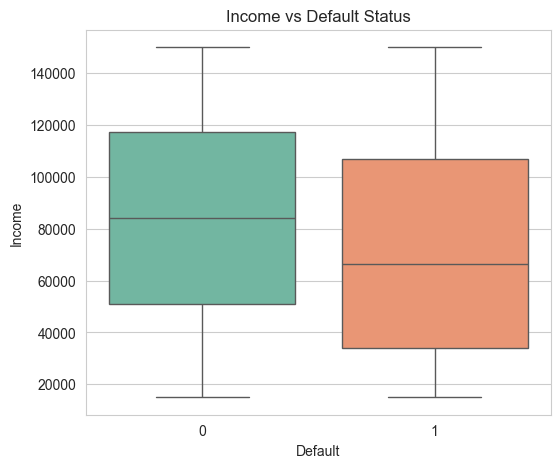

In [20]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Default', y='Income', data=df, palette='Set2')
plt.title("Income vs Default Status")
plt.show()

# Q14: Credit Score vs Default

C:\Users\DHAVAL TALAVIYA\AppData\Local\Temp\ipykernel_17848\3184318961.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Default', y='CreditScore', data=df, palette='Set2')


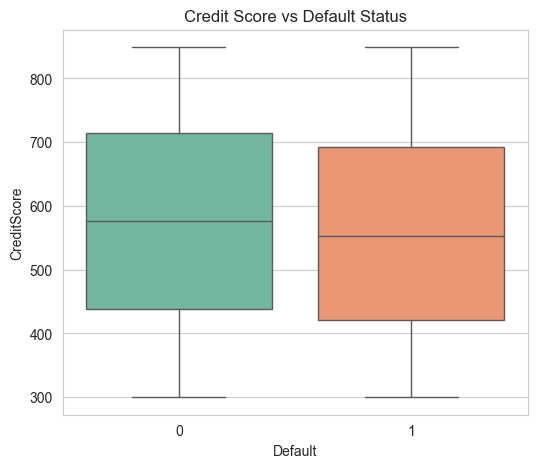

In [21]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Default', y='CreditScore', data=df, palette='Set2')
plt.title("Credit Score vs Default Status")
plt.show()

# Q15: Loan Amount vs Default

C:\Users\DHAVAL TALAVIYA\AppData\Local\Temp\ipykernel_17848\3697748882.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Default', y='LoanAmount', data=df, palette='Set2')


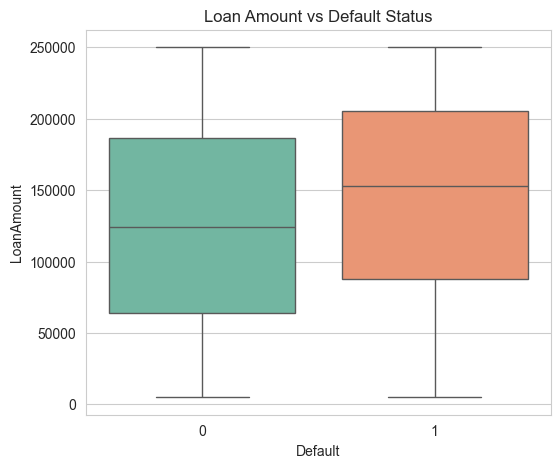

In [22]:
plt.figure(figsize=(6, 5))
sns.boxplot(x='Default', y='LoanAmount', data=df, palette='Set2')
plt.title("Loan Amount vs Default Status")
plt.show()

# Q16: Unique Values Check

In [23]:
print(df.nunique())

LoanID            255347
Age                   52
Income            114620
LoanAmount        158729
CreditScore          550
MonthsEmployed       120
NumCreditLines         4
InterestRate        2301
LoanTerm               5
DTIRatio              81
Education              4
EmploymentType         4
MaritalStatus          3
HasMortgage            2
HasDependents          2
LoanPurpose            5
HasCoSigner            2
Default                2
dtype: int64


# Q17: Top 5 Highest Incomes

In [24]:
print(df.nlargest(5, 'Income')[['LoanID', 'Income', 'Education']])

            LoanID  Income    Education
183400  ZQGVAT7T79  149999   Bachelor's
252244  VOXXF484TC  149999  High School
8905    W3UWERC20V  149997          PhD
203080  DFK5DI3QM7  149997   Bachelor's
25909   3MYPEH1E67  149996  High School


# Q18: List Column Names

In [25]:
print(df.columns.tolist())

['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default']


# Q19: Education Level vs Default

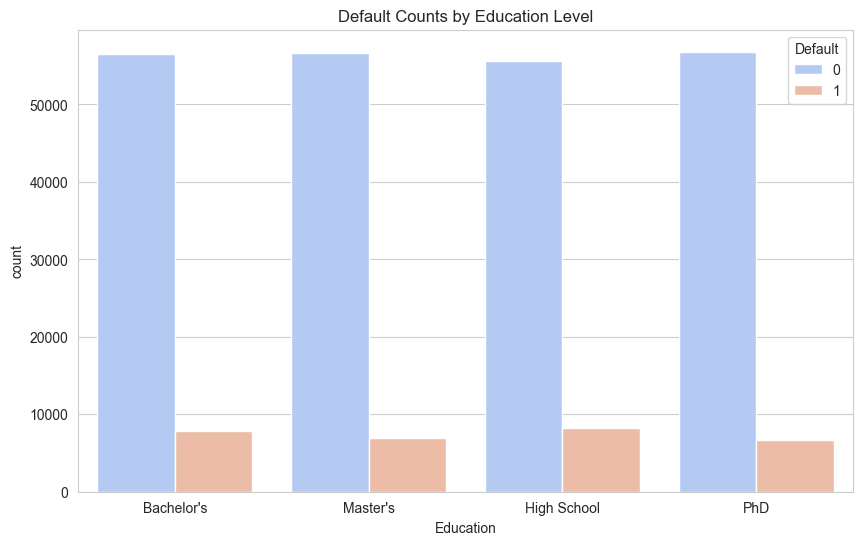

In [26]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Education', hue='Default', data=df, palette='coolwarm')
plt.title("Default Counts by Education Level")
plt.show()

## Part 4: Multivariate Analysis & Correlation

# Q20: Correlation Heatmap

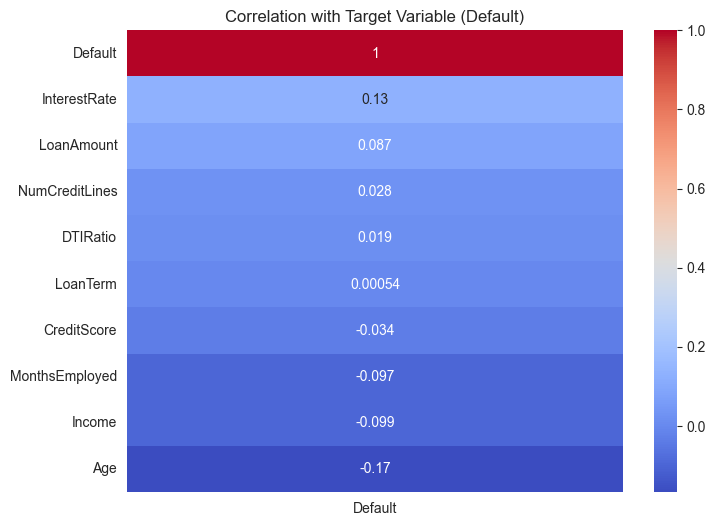

In [27]:
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
heatmap_data = numeric_df.corr()[['Default']].sort_values(by='Default', ascending=False)
sns.heatmap(heatmap_data, annot=True, cmap='coolwarm')
plt.title("Correlation with Target Variable (Default)")
plt.show()